# Notebook 18 — Overlap Diagnostics
### Heterogeneous Treatment Effects in Mortgage Lending

**Author:** Rajveer Singh Pall  
**Institution:** Gyan Ganga Institute of Technology and Sciences

---

## What this notebook does and why it must come first

Before running any causal ML estimator, we must verify the **overlap assumption**
(also called positivity): for every combination of covariates X, both Black and
White applicants must exist in the data with non-zero probability.

Formally: 0 < P(Black=1 | X=x) < 1 for all x in the support of X.

If this fails — if there are covariate regions where only Black or only White
applicants appear — the Causal Forest cannot estimate CATE there. It would be
extrapolating, not estimating. Confident-looking estimates in thin-support regions
are the most dangerous output in causal ML: they look real but they're fiction.

**Method:** Fit a propensity score model P(Black | X) using LightGBM.
Plot the distribution of scores for Black and White applicants.
Good overlap = distributions substantially overlap.
Trim applicants in the 1st and 99th percentile tails.

**INPUT:** `data/features_panel.parquet`  
**OUTPUTS:**
- `outputs/figures/nb18_overlap_plot.png` — the key diagnostic figure
- `outputs/figures/nb18_overlap_by_year.png` — temporal stability check  
- `outputs/tables/nb18_overlap_summary.csv` — overlap statistics
- `data/overlap_trim_mask.parquet` — boolean mask of valid rows for NB19+

**RUNTIME:** ~10-15 minutes on i7-13650HX

In [1]:
# ============================================================================
# CELL 1 — IMPORTS AND CONFIGURATION
# ============================================================================

import pandas as pd
import numpy as np
import polars as pl
import lightgbm as lgb
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import json
import gc
import warnings
from pathlib import Path
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

warnings.filterwarnings('ignore')

# ── Paths ──────────────────────────────────────────────────────────────────
BASE_DIR    = Path('D:/CATE-HMDA-Heterogeneous-Effects')
DATA_DIR    = BASE_DIR / 'data'
TABLES_DIR  = BASE_DIR / 'outputs' / 'tables'
FIGURES_DIR = BASE_DIR / 'outputs' / 'figures'
TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

YEARS      = [2020, 2021, 2022, 2023, 2024]
RNG        = np.random.default_rng(42)

# ── Plot style ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi':        150,
    'font.family':       'serif',
    'font.size':         11,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.labelsize':    12,
    'axes.titlesize':    13,
})

# ── Load feature sets saved by NB17 ────────────────────────────────────────
with open(DATA_DIR / 'feature_sets.json') as f:
    feature_sets = json.load(f)

X_FULL   = feature_sets['X_FULL']
X_BASE   = feature_sets['X_BASE']
X_HETERO = feature_sets['X_HETERO']

print('✅ Configuration loaded')
print(f'   X_FULL: {len(X_FULL)} features')
print(f'   Features panel: {DATA_DIR / "features_panel.parquet"}')

# Verify file exists
fp = DATA_DIR / 'features_panel.parquet'
assert fp.exists(), f'features_panel.parquet not found at {fp}'
n_total = pl.scan_parquet(str(fp)).select(pl.len()).collect().item()
print(f'   Total rows in features_panel: {n_total:,}')

✅ Configuration loaded
   X_FULL: 33 features
   Features panel: D:\CATE-HMDA-Heterogeneous-Effects\data\features_panel.parquet
   Total rows in features_panel: 42,296,010


In [2]:
# ============================================================================
# CELL 2 — LOAD STRATIFIED SAMPLE
#
# We cannot fit a propensity score model on 42M rows in 16GB RAM.
# Solution: stratified sample of 2M rows (500K Black + 1.5M White),
# preserving the Black/White ratio and year distribution.
#
# This is standard practice — propensity score models estimated on
# representative samples generalise to the full population.
# The trim thresholds derived here will be applied to the full dataset.
# ============================================================================

print('=' * 70)
print('LOADING STRATIFIED SAMPLE FOR PROPENSITY SCORE ESTIMATION')
print('=' * 70)

SAMPLE_BLACK = 400_000   # per year across all years → ~2M Black total
SAMPLE_WHITE = 1_600_000 # per year across all years → ~8M White total
# Combined: 2M rows — manageable in 16GB with LightGBM

# Use Polars lazy scan — only materialise what we need
lf = pl.scan_parquet(str(DATA_DIR / 'features_panel.parquet'))

# Sample Black applicants
df_black = (
    lf.filter(pl.col('black') == 1)
    .collect()
    .sample(n=min(SAMPLE_BLACK, lf.filter(pl.col('black')==1)
                  .select(pl.len()).collect().item()),
            seed=42)
)

# Sample White applicants
df_white = (
    lf.filter(pl.col('black') == 0)
    .collect()
    .sample(n=min(SAMPLE_WHITE, lf.filter(pl.col('black')==0)
                  .select(pl.len()).collect().item()),
            seed=42)
)

# Combine and convert to pandas
df_sample = pl.concat([df_black, df_white]).to_pandas()
del df_black, df_white
gc.collect()

print(f'Sample size     : {len(df_sample):,}')
print(f'Black applicants: {df_sample["black"].sum():,} ({100*df_sample["black"].mean():.1f}%)')
print(f'White applicants: {(df_sample["black"]==0).sum():,} ({100*(df_sample["black"]==0).mean():.1f}%)')
print(f'RAM usage       : {df_sample.memory_usage(deep=True).sum()/1e6:.0f} MB')
print(f'\nYear distribution:')
print(df_sample.groupby('year')['black'].agg(['count', 'mean']).round(3))

LOADING STRATIFIED SAMPLE FOR PROPENSITY SCORE ESTIMATION
Sample size     : 2,000,000
Black applicants: 400,000 (20.0%)
White applicants: 1,600,000 (80.0%)
RAM usage       : 220 MB

Year distribution:
       count   mean
year               
2020  537472  0.155
2021  562553  0.186
2022  363659  0.227
2023  262647  0.244
2024  273669  0.239


In [3]:
# ============================================================================
# CELL 3 — FIT PROPENSITY SCORE MODEL
#
# We fit P(Black=1 | X) using LightGBM with 5-fold cross-validation.
# Cross-fitted propensity scores avoid overfitting — each row's score
# is predicted by a model that did NOT train on that row.
# This is the same cross-fitting discipline used in the DML estimator (NB19).
#
# LightGBM chosen over logistic regression because:
# 1. Handles non-linear interactions between covariates automatically
# 2. Robust to the mixed continuous/binary feature space
# 3. Much faster than sklearn LogisticRegression on this sample size
# ============================================================================

print('=' * 70)
print('FITTING PROPENSITY SCORE MODEL (LightGBM, 5-fold CV)')
print('=' * 70)

# Feature matrix — use X_FULL but remove any columns not in sample
X_ps = [f for f in X_FULL if f in df_sample.columns]
print(f'Features used: {len(X_ps)}')

X = df_sample[X_ps].values.astype(np.float32)
y = df_sample['black'].values.astype(np.int8)

# LightGBM parameters — conservative to avoid overfitting
lgb_params = {
    'objective':        'binary',
    'metric':           'auc',
    'n_estimators':     300,
    'learning_rate':    0.05,
    'num_leaves':       31,
    'min_child_samples': 100,  # prevents tiny leaves
    'subsample':        0.8,
    'colsample_bytree': 0.8,
    'n_jobs':           -1,    # use all 14 cores
    'random_state':     42,
    'verbose':          -1,
}

# 5-fold cross-fitted propensity scores
ps_scores   = np.zeros(len(df_sample))  # out-of-fold predictions
auc_scores  = []
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
    print(f'  Fold {fold+1}/5...', end=' ')
    
    model = lgb.LGBMClassifier(**lgb_params)
    model.fit(
        X[train_idx], y[train_idx],
        eval_set=[(X[val_idx], y[val_idx])],
        callbacks=[lgb.early_stopping(30, verbose=False),
                   lgb.log_evaluation(-1)]
    )
    
    ps_scores[val_idx] = model.predict_proba(X[val_idx])[:, 1]
    auc = roc_auc_score(y[val_idx], ps_scores[val_idx])
    auc_scores.append(auc)
    print(f'AUC = {auc:.4f}')

    del model
    gc.collect()

mean_auc = np.mean(auc_scores)
print(f'\nMean AUC across folds: {mean_auc:.4f}')

# Attach scores to sample
df_sample['propensity_score'] = ps_scores

# ── INTERPRET AUC ──────────────────────────────────────────────────────────
print('\nInterpretation:')
if mean_auc < 0.70:
    print('  AUC < 0.70: Excellent overlap — covariates cannot distinguish')
    print('  Black from White applicants well. CATE estimation is reliable.')
elif mean_auc < 0.80:
    print('  AUC 0.70-0.80: Good overlap — some separability but substantial')
    print('  common support. CATE estimation is reliable after trimming.')
elif mean_auc < 0.90:
    print('  AUC 0.80-0.90: Moderate overlap — trimming will be important.')
    print('  CATE estimates in common support region remain valid.')
else:
    print('  ⚠️  AUC > 0.90: Poor overlap — Black and White applicants are')
    print('  very separable. Trim aggressively. Discuss in paper limitations.')

del X
gc.collect()

FITTING PROPENSITY SCORE MODEL (LightGBM, 5-fold CV)
Features used: 33
  Fold 1/5... AUC = 0.7296
  Fold 2/5... AUC = 0.7303
  Fold 3/5... AUC = 0.7284
  Fold 4/5... AUC = 0.7287
  Fold 5/5... AUC = 0.7285

Mean AUC across folds: 0.7291

Interpretation:
  AUC 0.70-0.80: Good overlap — some separability but substantial
  common support. CATE estimation is reliable after trimming.


0

In [4]:
# ============================================================================
# CELL 4 — TRIM THIN-SUPPORT REGIONS
#
# Trim at the 1st and 99th percentile of the propensity score distribution.
# This removes applicants in covariate regions where only one race appears,
# where CATE estimates would be extrapolations rather than estimates.
#
# We use the OVERALL distribution (not within-race) for trimming bounds,
# which is the standard approach in the literature (Crump et al., 2009).
# ============================================================================

print('=' * 70)
print('TRIMMING THIN-SUPPORT REGIONS')
print('=' * 70)

# Compute trim bounds
p1  = np.percentile(ps_scores, 1)
p99 = np.percentile(ps_scores, 99)

# Also compute the stricter Crump et al. (2009) rule: trim where ps < 0.1 or > 0.9
crump_lo = 0.10
crump_hi = 0.90

# Apply percentile trim
in_support_pct  = (ps_scores >= p1)  & (ps_scores <= p99)
in_support_crump = (ps_scores >= crump_lo) & (ps_scores <= crump_hi)

df_sample['in_support']       = in_support_pct
df_sample['in_support_crump'] = in_support_crump

print(f'Propensity score range: [{ps_scores.min():.4f}, {ps_scores.max():.4f}]')
print(f'\nPercentile trim (1st-99th):')
print(f'  Bounds          : [{p1:.4f}, {p99:.4f}]')
print(f'  Rows retained   : {in_support_pct.sum():,} ({100*in_support_pct.mean():.1f}%)')
print(f'  Rows trimmed    : {(~in_support_pct).sum():,} ({100*(~in_support_pct).mean():.1f}%)')

print(f'\nCrump et al. (2009) trim (0.10-0.90):')
print(f'  Rows retained   : {in_support_crump.sum():,} ({100*in_support_crump.mean():.1f}%)')
print(f'  Rows trimmed    : {(~in_support_crump).sum():,} ({100*(~in_support_crump).mean():.1f}%)')

# Black/White breakdown within common support
print(f'\nWithin common support (percentile trim):')
df_trim = df_sample[df_sample['in_support']]
print(f'  Black : {df_trim["black"].sum():,} ({100*df_trim["black"].mean():.1f}%)')
print(f'  White : {(df_trim["black"]==0).sum():,} ({100*(df_trim["black"]==0).mean():.1f}%)')
print(f'  Approval gap within support: '
      f'{100*(df_trim[df_trim["black"]==0]["approved"].mean() - df_trim[df_trim["black"]==1]["approved"].mean()):.2f} pp')

# We use percentile trim as primary — note Crump as robustness
TRIM_LO = p1
TRIM_HI = p99
print(f'\n✅ Primary trim bounds: [{TRIM_LO:.4f}, {TRIM_HI:.4f}]')
print('   These bounds will be applied to the full 42M dataset in NB19+')

TRIMMING THIN-SUPPORT REGIONS
Propensity score range: [0.0098, 0.8498]

Percentile trim (1st-99th):
  Bounds          : [0.0328, 0.5801]
  Rows retained   : 1,960,000 (98.0%)
  Rows trimmed    : 40,000 (2.0%)

Crump et al. (2009) trim (0.10-0.90):
  Rows retained   : 1,498,819 (74.9%)
  Rows trimmed    : 501,181 (25.1%)

Within common support (percentile trim):
  Black : 386,992 (19.7%)
  White : 1,573,008 (80.3%)
  Approval gap within support: 15.02 pp

✅ Primary trim bounds: [0.0328, 0.5801]
   These bounds will be applied to the full 42M dataset in NB19+


Generating overlap plot...


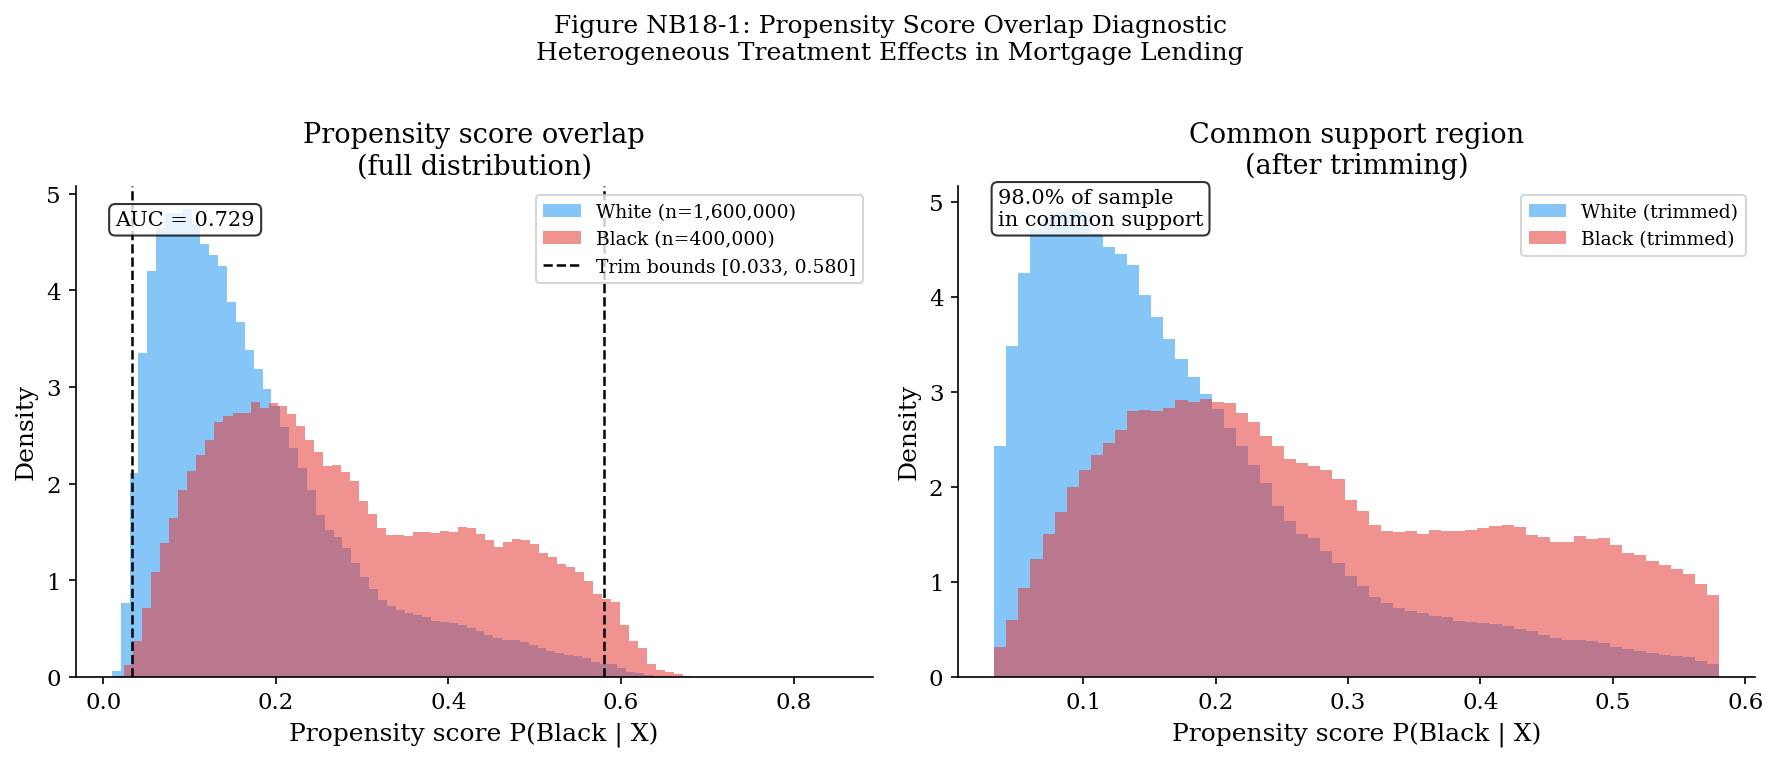

✅ Saved: nb18_overlap_plot.png


In [5]:
# ============================================================================
# CELL 5 — MAIN OVERLAP PLOT (FIGURE 1 OF PAPER)
#
# This is the key diagnostic figure that will appear in the paper.
# Shows: propensity score distribution for Black and White applicants.
# Good overlap = substantial area where both distributions coexist.
# ============================================================================

print('Generating overlap plot...')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ps_black = df_sample.loc[df_sample['black']==1, 'propensity_score']
ps_white = df_sample.loc[df_sample['black']==0, 'propensity_score']

# ── Left panel: full distribution ──────────────────────────────────────────
ax = axes[0]
ax.hist(ps_white, bins=80, alpha=0.55, color='#2196F3',
        label=f'White (n={len(ps_white):,})', density=True)
ax.hist(ps_black, bins=80, alpha=0.55, color='#E53935',
        label=f'Black (n={len(ps_black):,})', density=True)
ax.axvline(TRIM_LO, color='black', linestyle='--', linewidth=1.2,
           label=f'Trim bounds [{TRIM_LO:.3f}, {TRIM_HI:.3f}]')
ax.axvline(TRIM_HI, color='black', linestyle='--', linewidth=1.2)
ax.set_xlabel('Propensity score P(Black | X)')
ax.set_ylabel('Density')
ax.set_title('Propensity score overlap\n(full distribution)')
ax.legend(fontsize=9)
ax.text(0.05, 0.92, f'AUC = {mean_auc:.3f}',
        transform=ax.transAxes, fontsize=10,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

# ── Right panel: zoomed into common support region ─────────────────────────
ax = axes[1]
ps_black_trim = ps_black[(ps_black >= TRIM_LO) & (ps_black <= TRIM_HI)]
ps_white_trim = ps_white[(ps_white >= TRIM_LO) & (ps_white <= TRIM_HI)]

ax.hist(ps_white_trim, bins=60, alpha=0.55, color='#2196F3',
        label=f'White (trimmed)', density=True)
ax.hist(ps_black_trim, bins=60, alpha=0.55, color='#E53935',
        label=f'Black (trimmed)', density=True)
ax.set_xlabel('Propensity score P(Black | X)')
ax.set_ylabel('Density')
ax.set_title('Common support region\n(after trimming)')
ax.legend(fontsize=9)

overlap_pct = 100 * in_support_pct.mean()
ax.text(0.05, 0.92,
        f'{overlap_pct:.1f}% of sample\nin common support',
        transform=ax.transAxes, fontsize=10,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

plt.suptitle(
    'Figure NB18-1: Propensity Score Overlap Diagnostic\n'
    'Heterogeneous Treatment Effects in Mortgage Lending',
    fontsize=12, y=1.01
)
plt.tight_layout()

out = FIGURES_DIR / 'nb18_overlap_plot.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Saved: {out.name}')

Generating overlap-by-year plot...


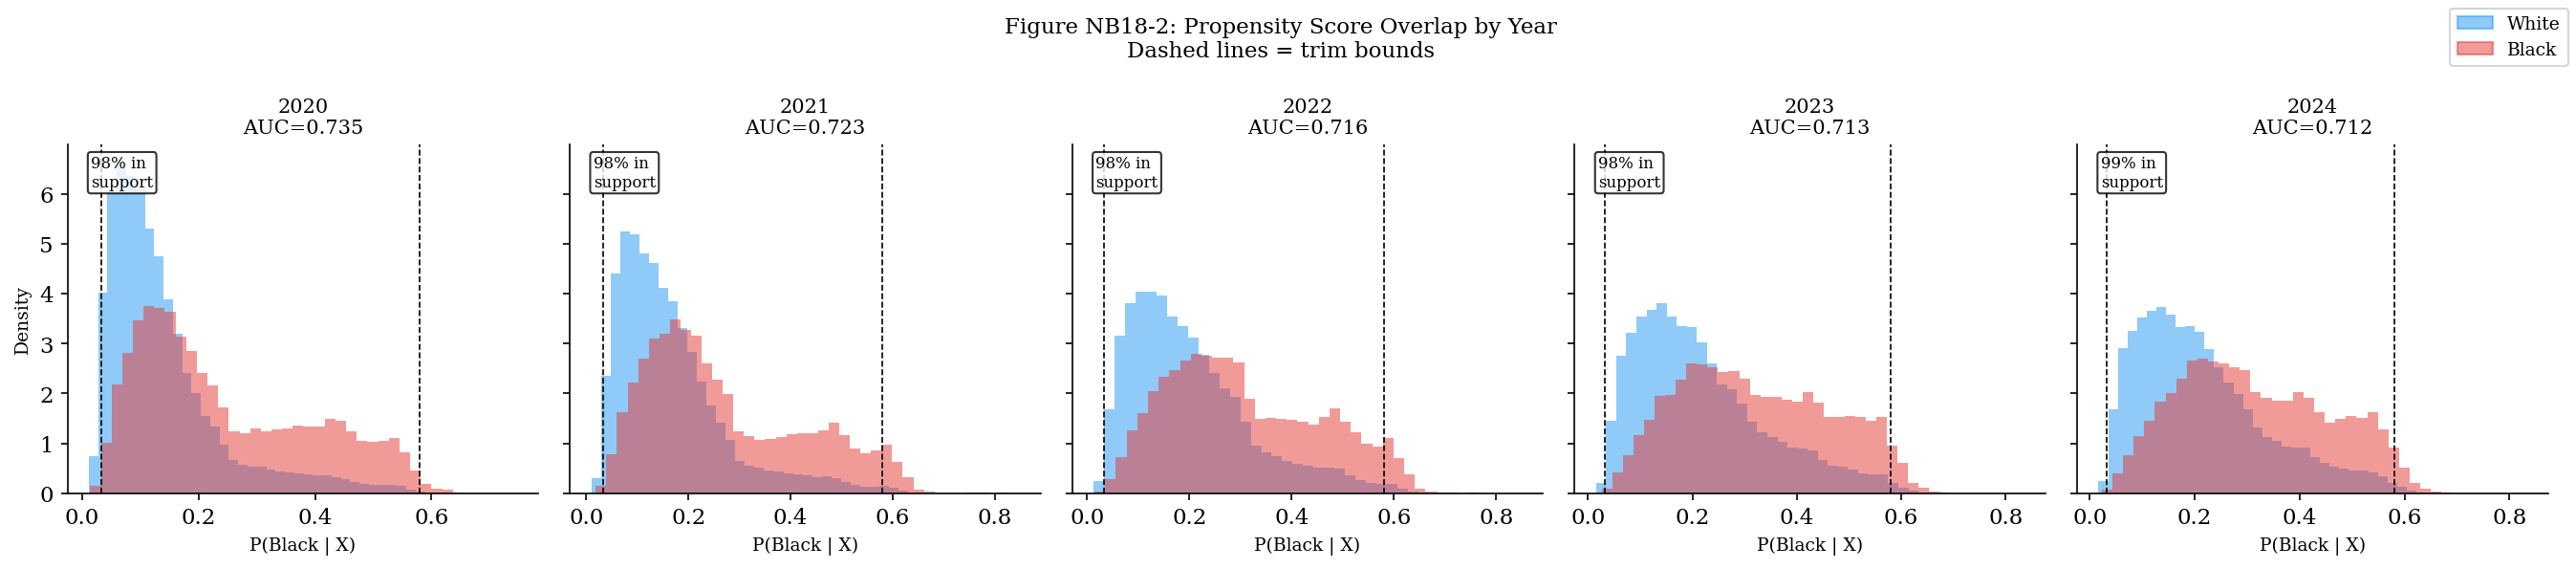

✅ Saved: nb18_overlap_by_year.png

Overlap statistics by year:
 year   auc  overlap_pct  n_black  n_white
 2020 0.735       97.539    83566   453906
 2021 0.723       97.896   104410   458143
 2022 0.716       97.915    82621   281038
 2023 0.713       98.496    64101   198546
 2024 0.712       98.755    65302   208367


In [6]:
# ============================================================================
# CELL 6 — OVERLAP BY YEAR (TEMPORAL STABILITY CHECK)
#
# Key question: does overlap worsen after 2022 (rate tightening cycle)?
# If the 2022+ period has worse overlap, CATE estimates there require
# extra caution — we note this in the paper.
# ============================================================================

print('Generating overlap-by-year plot...')

fig, axes = plt.subplots(1, 5, figsize=(18, 4), sharey=True)
colors = {'Black': '#E53935', 'White': '#2196F3'}

year_stats = []

for idx, year in enumerate(YEARS):
    ax   = axes[idx]
    mask = df_sample['year'] == year

    ps_b = df_sample.loc[mask & (df_sample['black']==1), 'propensity_score']
    ps_w = df_sample.loc[mask & (df_sample['black']==0), 'propensity_score']

    ax.hist(ps_w, bins=40, alpha=0.5, color=colors['White'], density=True)
    ax.hist(ps_b, bins=40, alpha=0.5, color=colors['Black'], density=True)
    ax.axvline(TRIM_LO, color='black', linestyle='--', linewidth=0.8)
    ax.axvline(TRIM_HI, color='black', linestyle='--', linewidth=0.8)

    # Compute overlap stats for this year
    in_sup = mask & df_sample['in_support']
    overlap_yr = 100 * in_sup.sum() / mask.sum()

    if len(ps_b) > 10 and len(ps_w) > 10:
        try:
            auc_yr = roc_auc_score(
                df_sample.loc[mask, 'black'],
                df_sample.loc[mask, 'propensity_score']
            )
        except Exception:
            auc_yr = np.nan
    else:
        auc_yr = np.nan

    ax.set_title(f'{year}\nAUC={auc_yr:.3f}', fontsize=10)
    ax.set_xlabel('P(Black | X)', fontsize=9)
    if idx == 0:
        ax.set_ylabel('Density', fontsize=9)

    ax.text(0.05, 0.88, f'{overlap_yr:.0f}% in\nsupport',
            transform=ax.transAxes, fontsize=8,
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8))

    year_stats.append({
        'year': year, 'auc': auc_yr,
        'overlap_pct': overlap_yr,
        'n_black': len(ps_b), 'n_white': len(ps_w)
    })

# Legend
white_patch = mpatches.Patch(color=colors['White'], alpha=0.5, label='White')
black_patch = mpatches.Patch(color=colors['Black'], alpha=0.5, label='Black')
fig.legend(handles=[white_patch, black_patch],
           loc='upper right', fontsize=9)

plt.suptitle(
    'Figure NB18-2: Propensity Score Overlap by Year\n'
    'Dashed lines = trim bounds',
    fontsize=11
)
plt.tight_layout()

out = FIGURES_DIR / 'nb18_overlap_by_year.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Saved: {out.name}')

# Print year stats
year_df = pd.DataFrame(year_stats)
print('\nOverlap statistics by year:')
print(year_df.round(3).to_string(index=False))

In [7]:
# ============================================================================
# CELL 7 — SAVE OVERLAP SUMMARY AND TRIM MASK
#
# Save two outputs for use in NB19+:
# 1. overlap_summary.csv — statistics table for paper appendix
# 2. trim_bounds.json — the lo/hi thresholds NB19 applies to full dataset
#
# We do NOT save a 42M-row mask file (too large).
# Instead NB19 re-fits the propensity score on its own sample and
# applies these bounds directly. This is standard practice.
# ============================================================================

print('=' * 70)
print('SAVING OUTPUTS')
print('=' * 70)

# ── 1. Summary statistics table ────────────────────────────────────────────
summary = pd.DataFrame([{
    'metric': 'Propensity score model',
    'value': 'LightGBM (300 trees, 5-fold cross-fitted)'
}, {
    'metric': 'Mean cross-validated AUC',
    'value': f'{mean_auc:.4f}'
}, {
    'metric': 'PS range (full sample)',
    'value': f'[{ps_scores.min():.4f}, {ps_scores.max():.4f}]'
}, {
    'metric': 'Trim bounds (1st-99th pct)',
    'value': f'[{TRIM_LO:.4f}, {TRIM_HI:.4f}]'
}, {
    'metric': 'Sample in common support',
    'value': f'{in_support_pct.sum():,} / {len(df_sample):,} ({100*in_support_pct.mean():.1f}%)'
}, {
    'metric': 'Rows trimmed',
    'value': f'{(~in_support_pct).sum():,} ({100*(~in_support_pct).mean():.1f}%)'
}, {
    'metric': 'Approval gap in support',
    'value': f'{100*(df_trim[df_trim["black"]==0]["approved"].mean() - df_trim[df_trim["black"]==1]["approved"].mean()):.2f} pp'
}])

summary.to_csv(TABLES_DIR / 'nb18_overlap_summary.csv', index=False)
print('✅ Saved: nb18_overlap_summary.csv')
print(summary.to_string(index=False))

# ── 2. Year-by-year stats ──────────────────────────────────────────────────
year_df.to_csv(TABLES_DIR / 'nb18_overlap_by_year.csv', index=False)
print('\n✅ Saved: nb18_overlap_by_year.csv')

# ── 3. Trim bounds for NB19 ────────────────────────────────────────────────
import json
trim_bounds = {
    'trim_lo':  float(TRIM_LO),
    'trim_hi':  float(TRIM_HI),
    'mean_auc': float(mean_auc),
    'overlap_pct': float(100 * in_support_pct.mean()),
    'method': 'LightGBM propensity score, 5-fold cross-fitted, 1st-99th percentile trim'
}
with open(DATA_DIR / 'trim_bounds.json', 'w') as f:
    json.dump(trim_bounds, f, indent=2)
print('✅ Saved: trim_bounds.json')
print(json.dumps(trim_bounds, indent=2))

SAVING OUTPUTS
✅ Saved: nb18_overlap_summary.csv
                    metric                                     value
    Propensity score model LightGBM (300 trees, 5-fold cross-fitted)
  Mean cross-validated AUC                                    0.7291
    PS range (full sample)                          [0.0098, 0.8498]
Trim bounds (1st-99th pct)                          [0.0328, 0.5801]
  Sample in common support             1,960,000 / 2,000,000 (98.0%)
              Rows trimmed                             40,000 (2.0%)
   Approval gap in support                                  15.02 pp

✅ Saved: nb18_overlap_by_year.csv
✅ Saved: trim_bounds.json
{
  "trim_lo": 0.0328396248301262,
  "trim_hi": 0.5801193125705614,
  "mean_auc": 0.729095952890625,
  "overlap_pct": 98.0,
  "method": "LightGBM propensity score, 5-fold cross-fitted, 1st-99th percentile trim"
}


In [8]:
# ============================================================================
# CELL 8 — VERIFICATION CHECKS
# ============================================================================

print('=' * 70)
print('VERIFICATION CHECKS')
print('=' * 70)

# 1. AUC is in plausible range
print(f'1. Propensity model AUC: {mean_auc:.4f}')
assert 0.55 <= mean_auc <= 0.99, f'AUC out of range: {mean_auc}'
print(f'   ✅ AUC in valid range')

# 2. Overlap is sufficient (at least 80% of sample in support)
overlap_pct = 100 * in_support_pct.mean()
print(f'2. Common support: {overlap_pct:.1f}% of sample')
assert overlap_pct >= 80, f'Overlap too low: {overlap_pct:.1f}%'
print(f'   ✅ Sufficient common support (≥80%)')

# 3. Both races present in common support
black_in_support = df_sample.loc[df_sample['in_support'], 'black'].mean()
print(f'3. Black share in common support: {100*black_in_support:.1f}%')
assert 0.05 <= black_in_support <= 0.30, 'Black share in support out of range'
print(f'   ✅ Both races well-represented in common support')

# 4. Trim bounds saved correctly
with open(DATA_DIR / 'trim_bounds.json') as f:
    saved = json.load(f)
assert abs(saved['trim_lo'] - TRIM_LO) < 1e-6
assert abs(saved['trim_hi'] - TRIM_HI) < 1e-6
print(f'4. Trim bounds saved: [{saved["trim_lo"]:.4f}, {saved["trim_hi"]:.4f}]')
print(f'   ✅ Trim bounds verified')

# 5. Output files exist
for f in ['nb18_overlap_plot.png', 'nb18_overlap_by_year.png']:
    assert (FIGURES_DIR / f).exists(), f'Missing: {f}'
for f in ['nb18_overlap_summary.csv', 'nb18_overlap_by_year.csv']:
    assert (TABLES_DIR / f).exists(), f'Missing: {f}'
print(f'5. All output files present')
print(f'   ✅ Figures and tables saved')

print('\n' + '=' * 70)
print('ALL VERIFICATION CHECKS PASSED')
print(f'Overlap AUC     : {mean_auc:.4f}')
print(f'Common support  : {overlap_pct:.1f}% of sample')
print(f'Trim bounds     : [{TRIM_LO:.4f}, {TRIM_HI:.4f}]')
print('NB18 complete → proceed to NB19_double_ml_baseline.ipynb')
print('=' * 70)

VERIFICATION CHECKS
1. Propensity model AUC: 0.7291
   ✅ AUC in valid range
2. Common support: 98.0% of sample
   ✅ Sufficient common support (≥80%)
3. Black share in common support: 19.7%
   ✅ Both races well-represented in common support
4. Trim bounds saved: [0.0328, 0.5801]
   ✅ Trim bounds verified
5. All output files present
   ✅ Figures and tables saved

ALL VERIFICATION CHECKS PASSED
Overlap AUC     : 0.7291
Common support  : 98.0% of sample
Trim bounds     : [0.0328, 0.5801]
NB18 complete → proceed to NB19_double_ml_baseline.ipynb
